In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Dataset shape: (2000, 14)
label
0    1000
1    1000
Name: count, dtype: int64


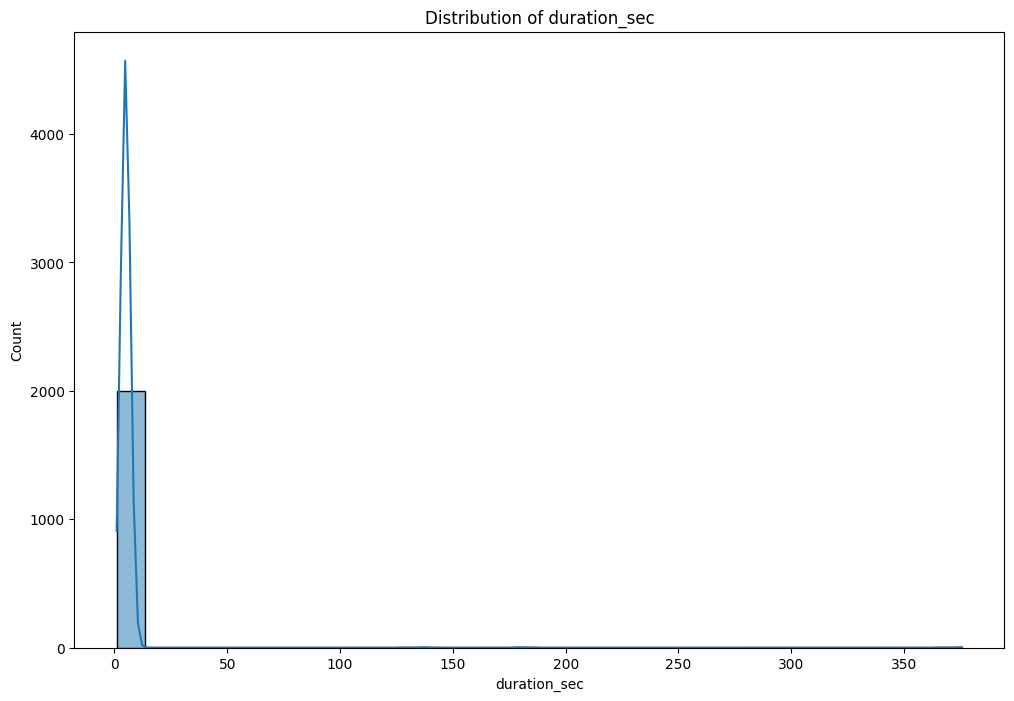

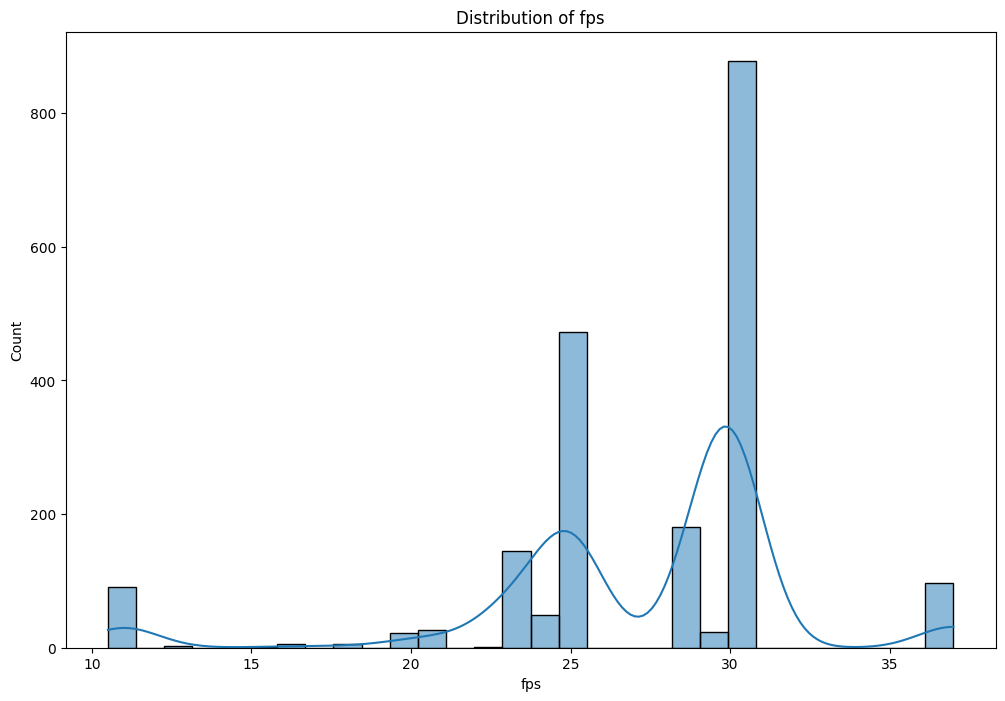

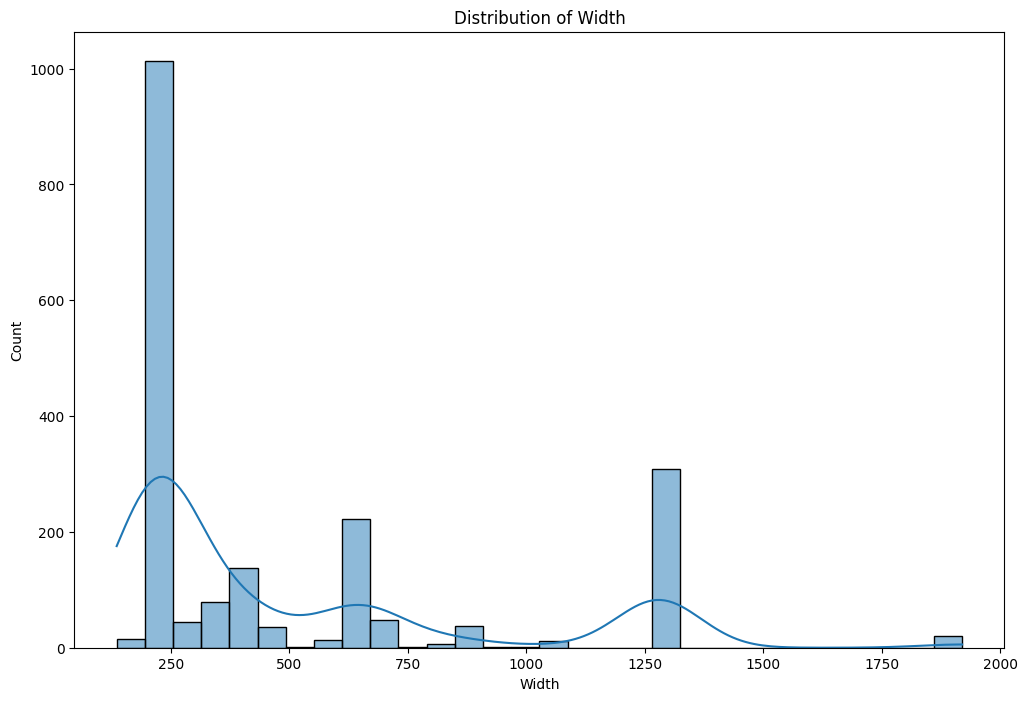

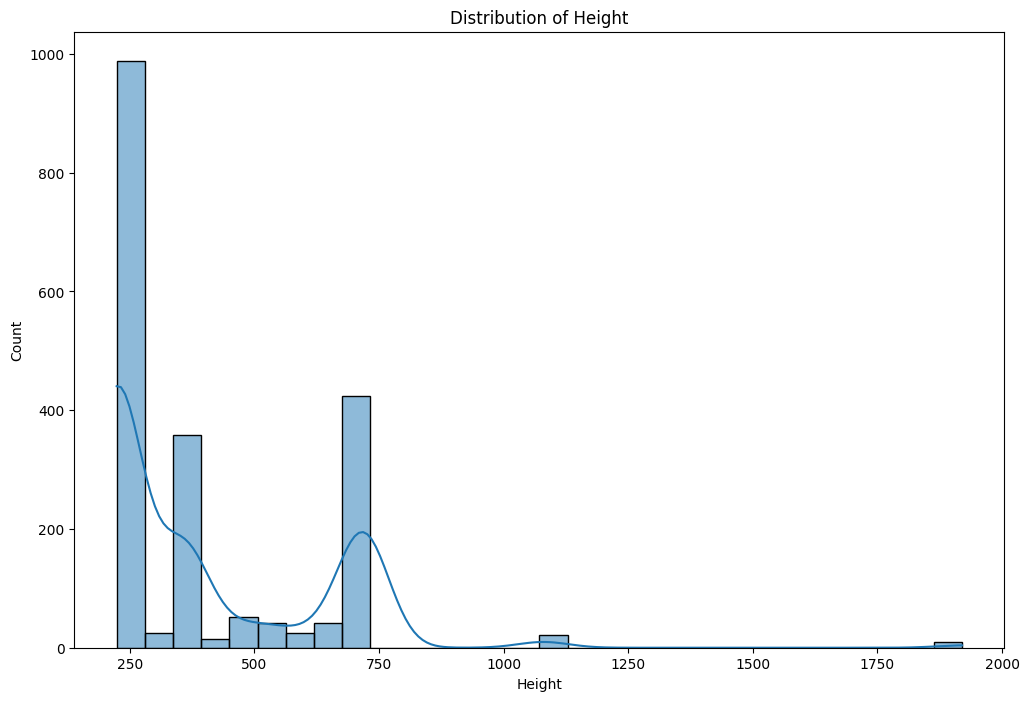

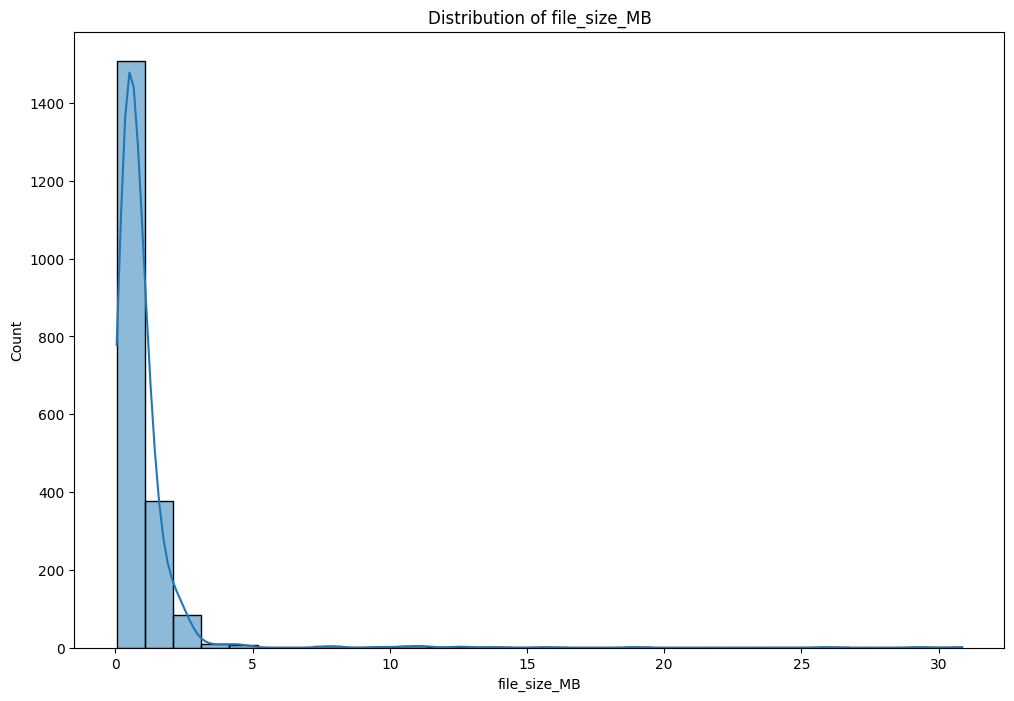

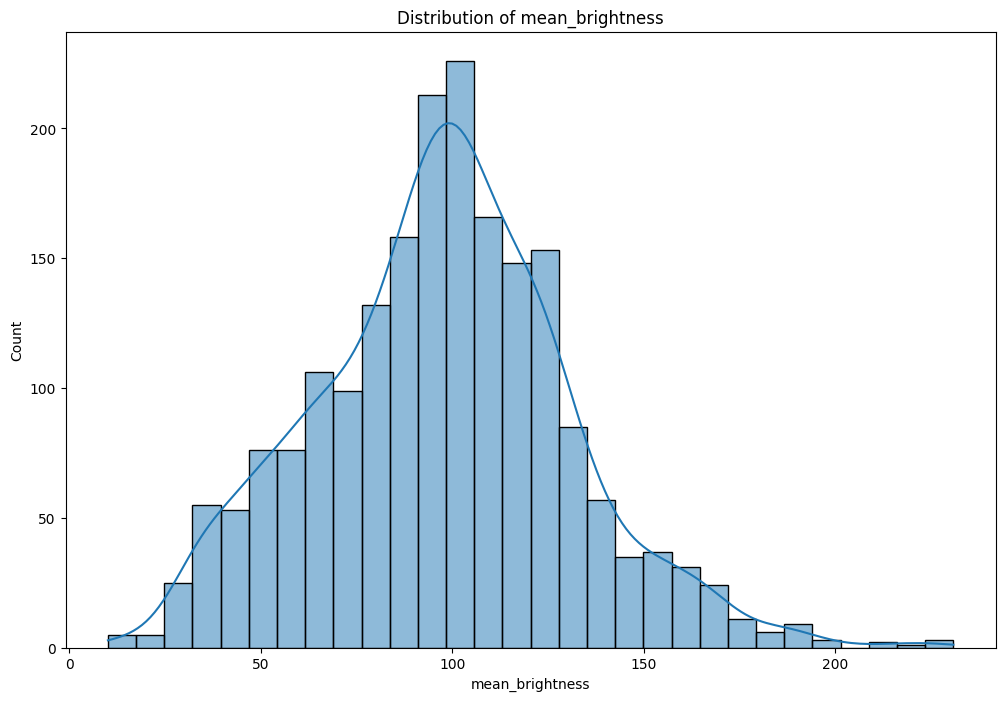

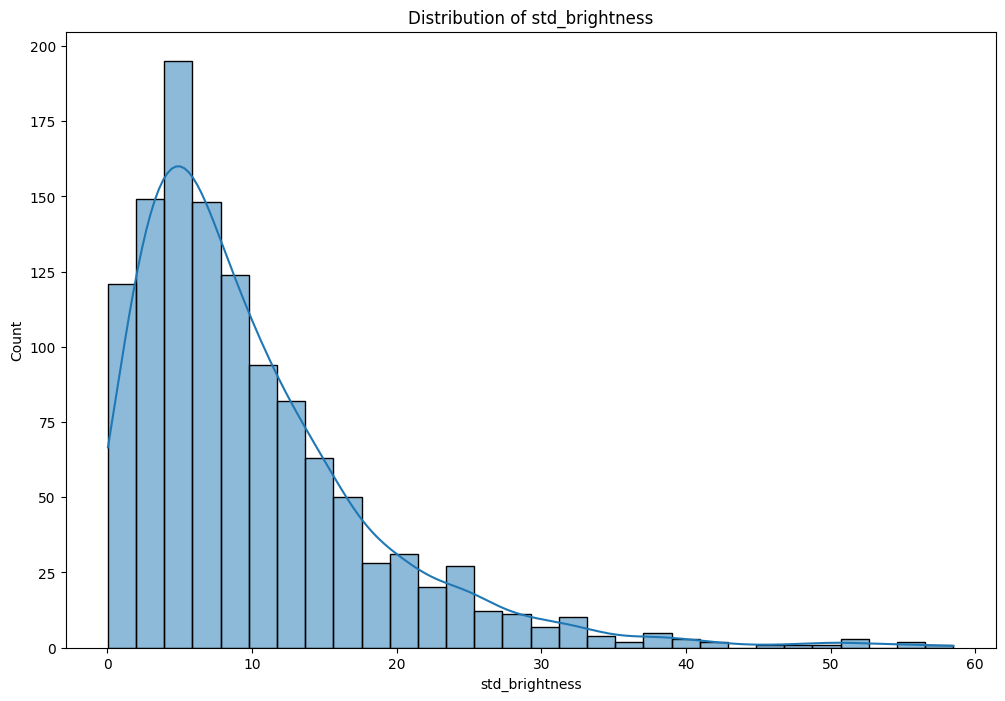

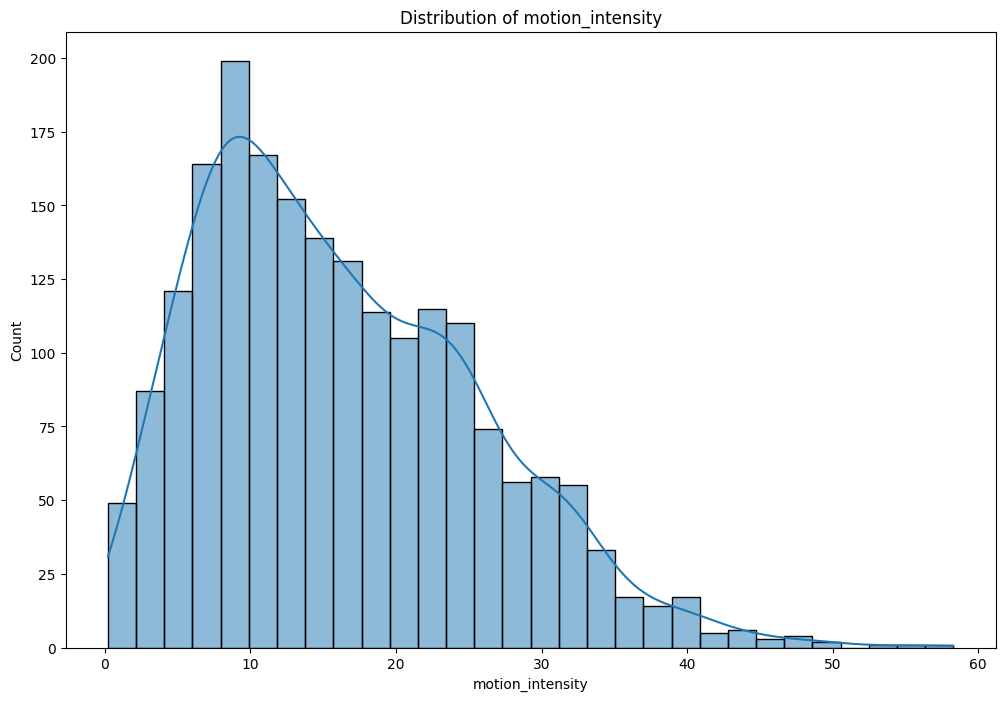

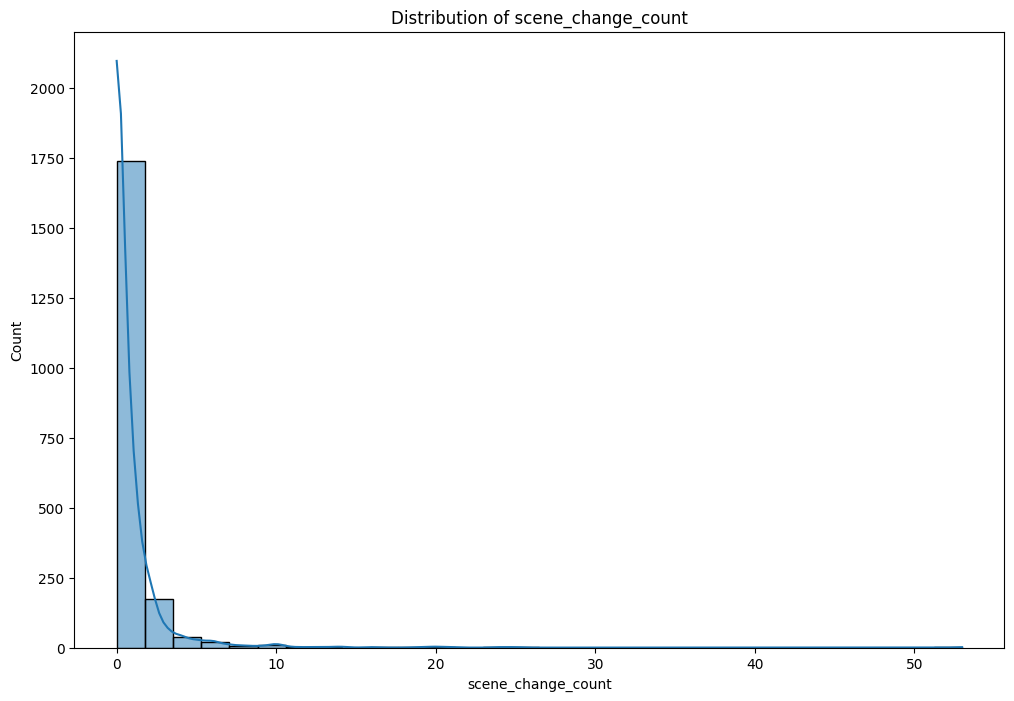

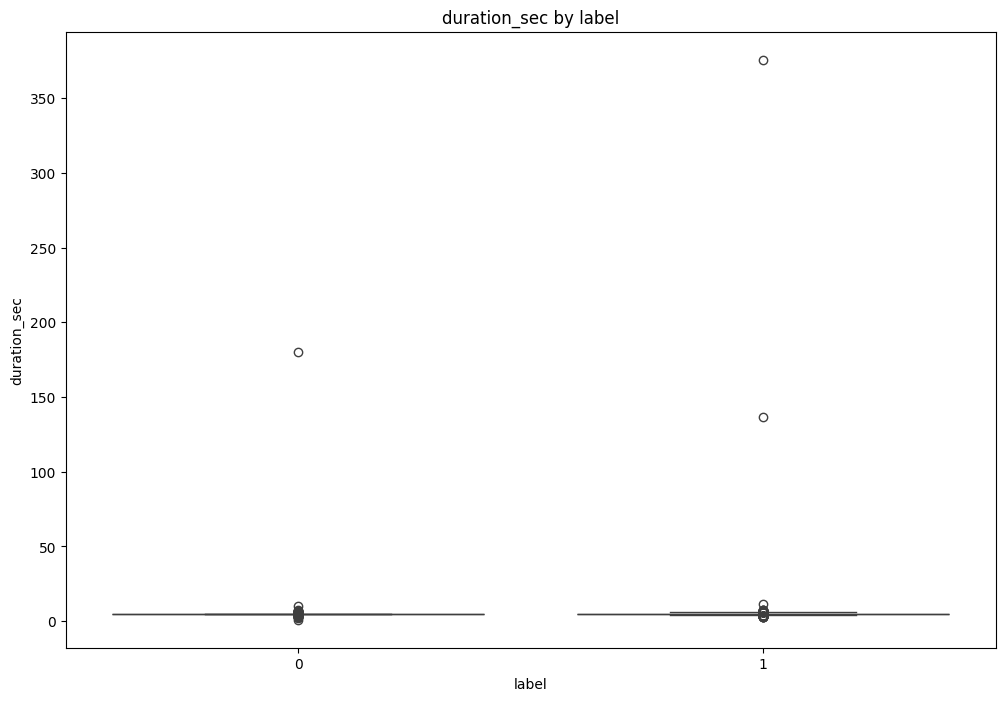

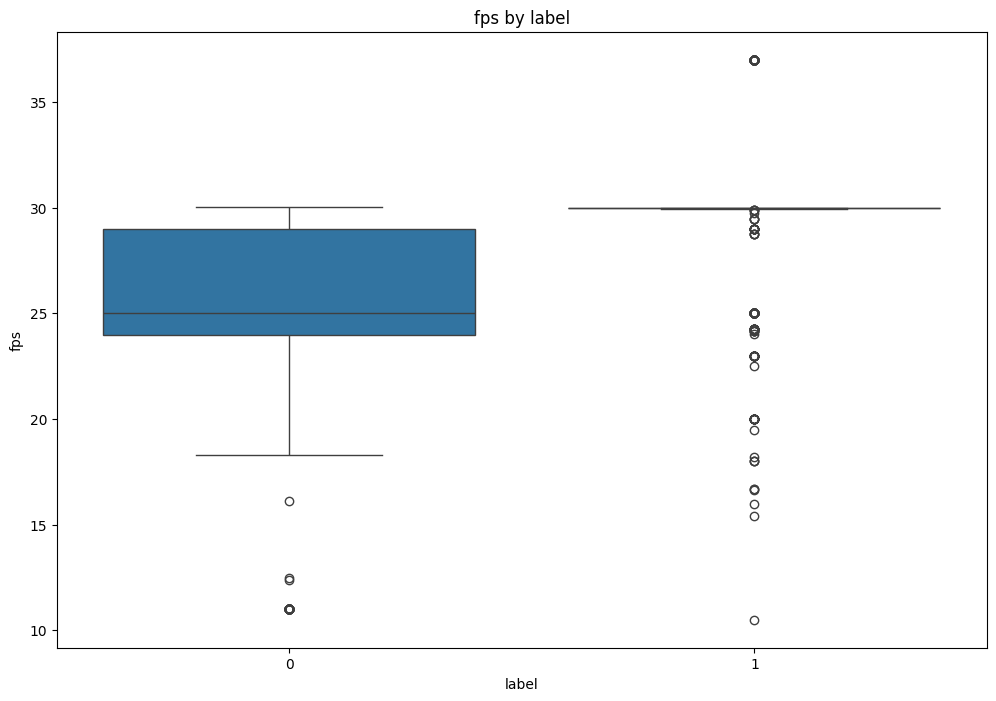

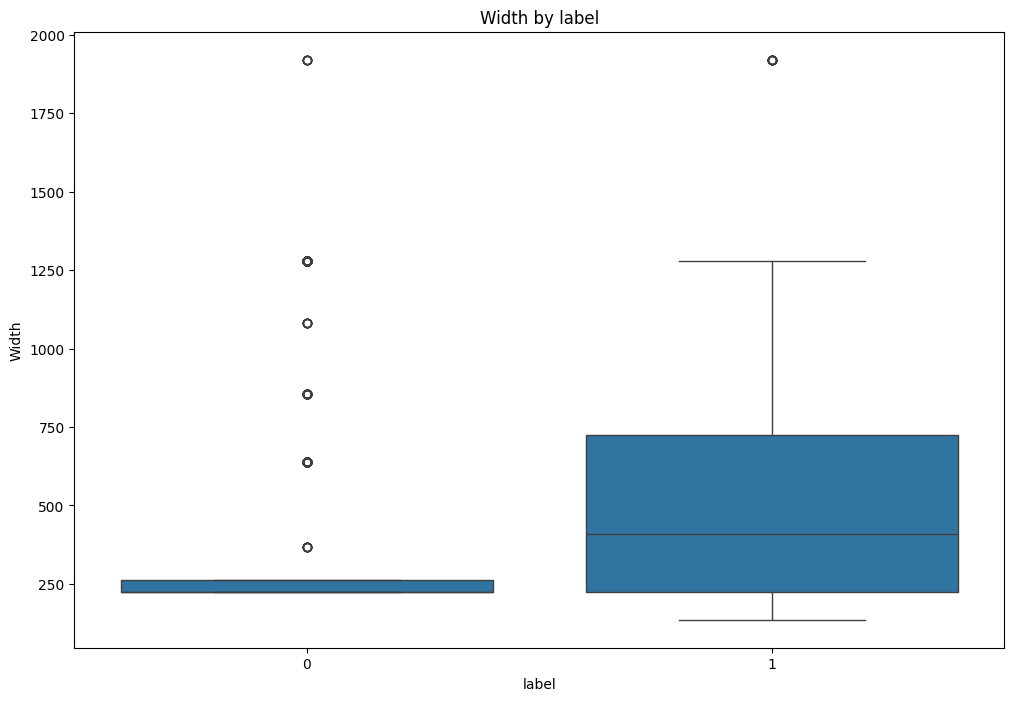

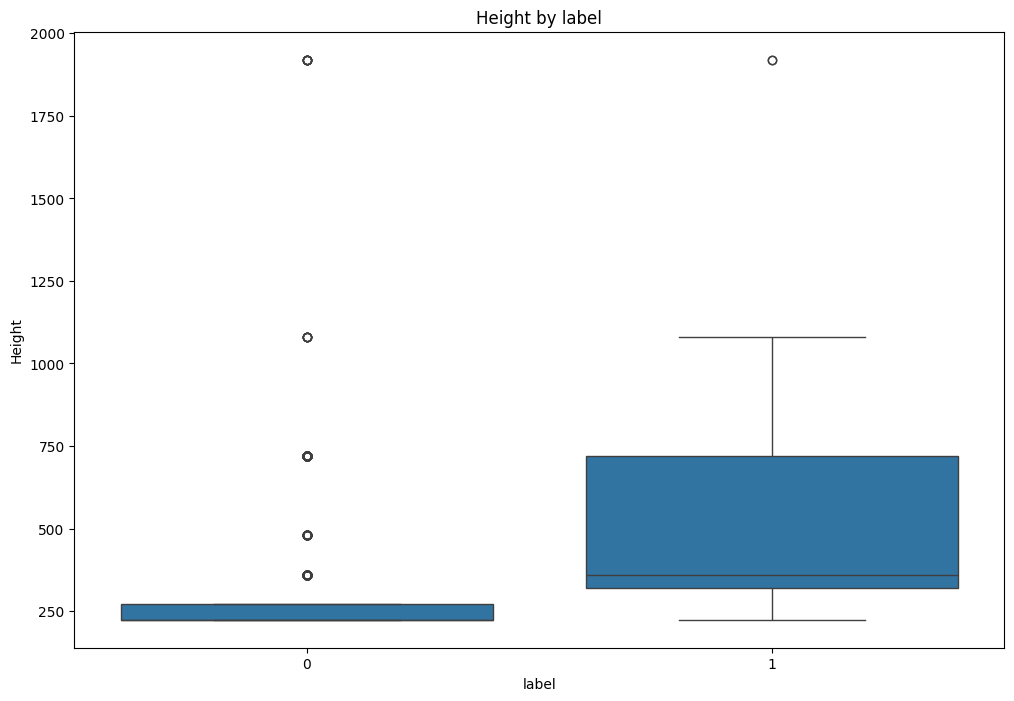

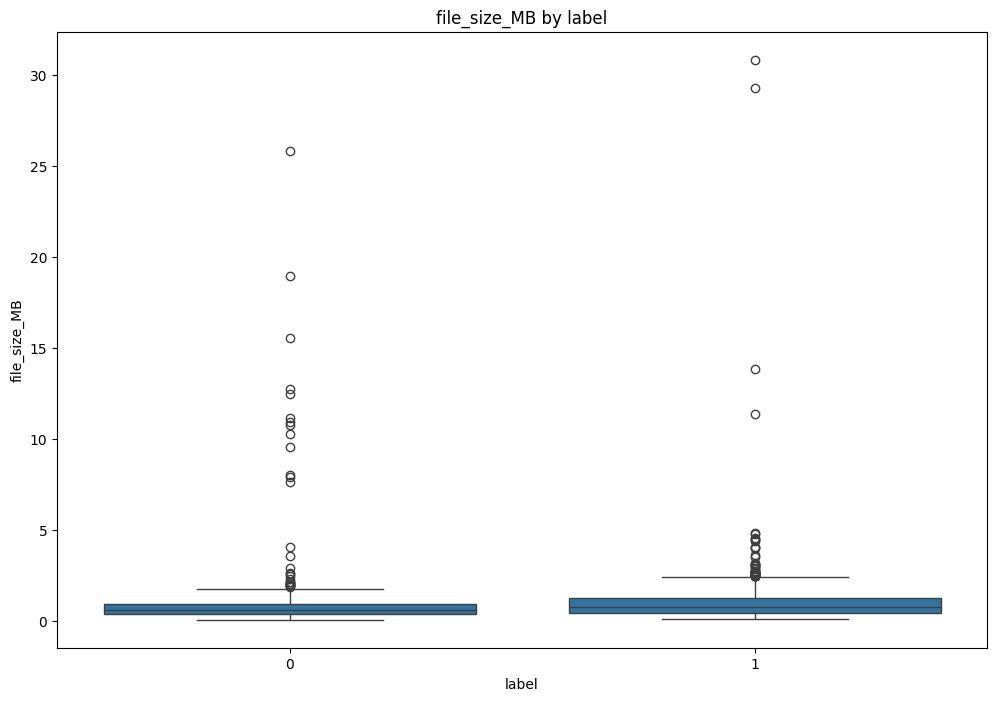

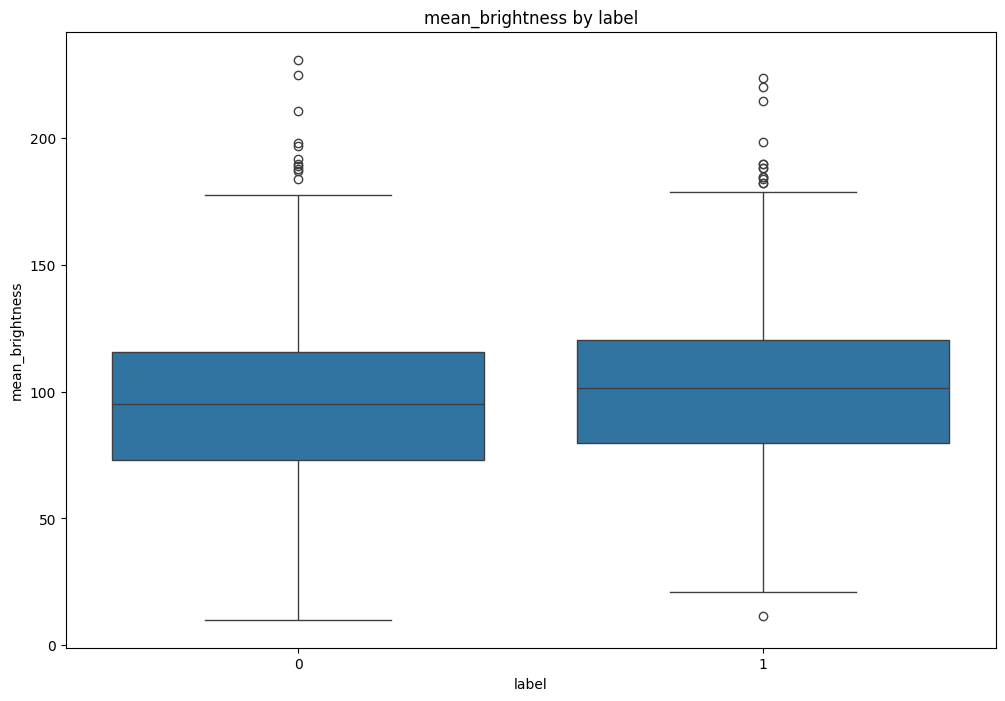

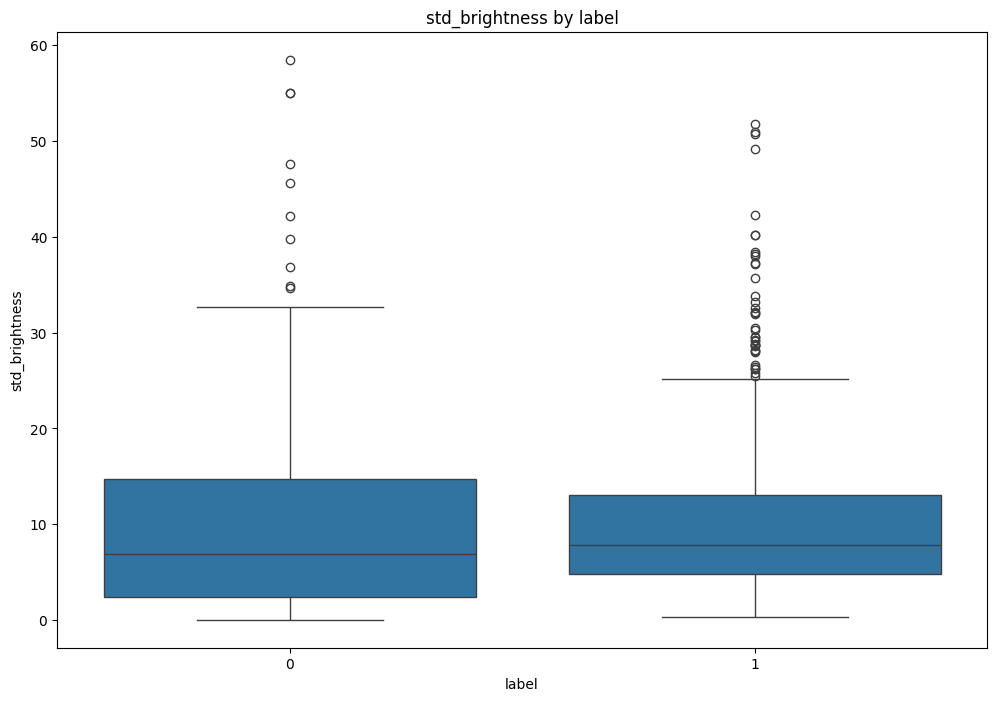

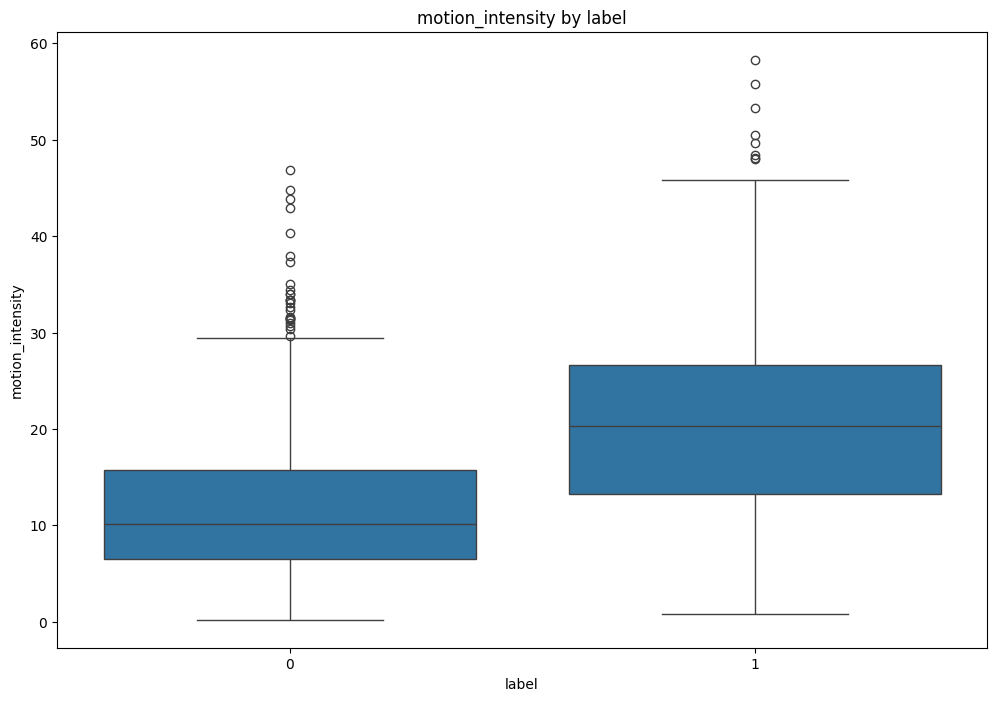

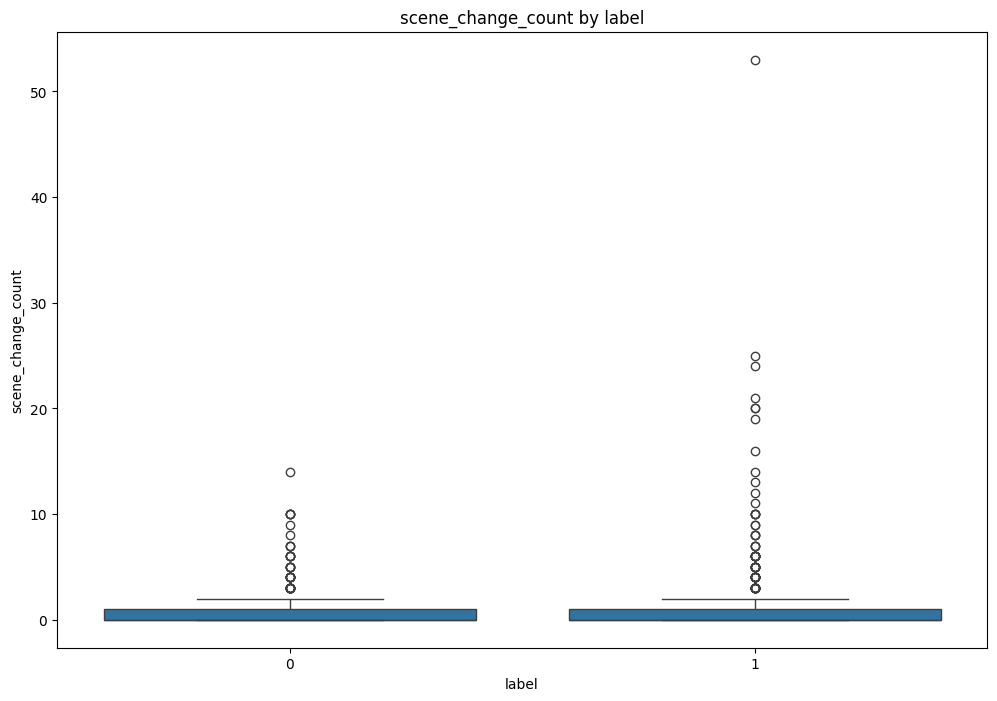

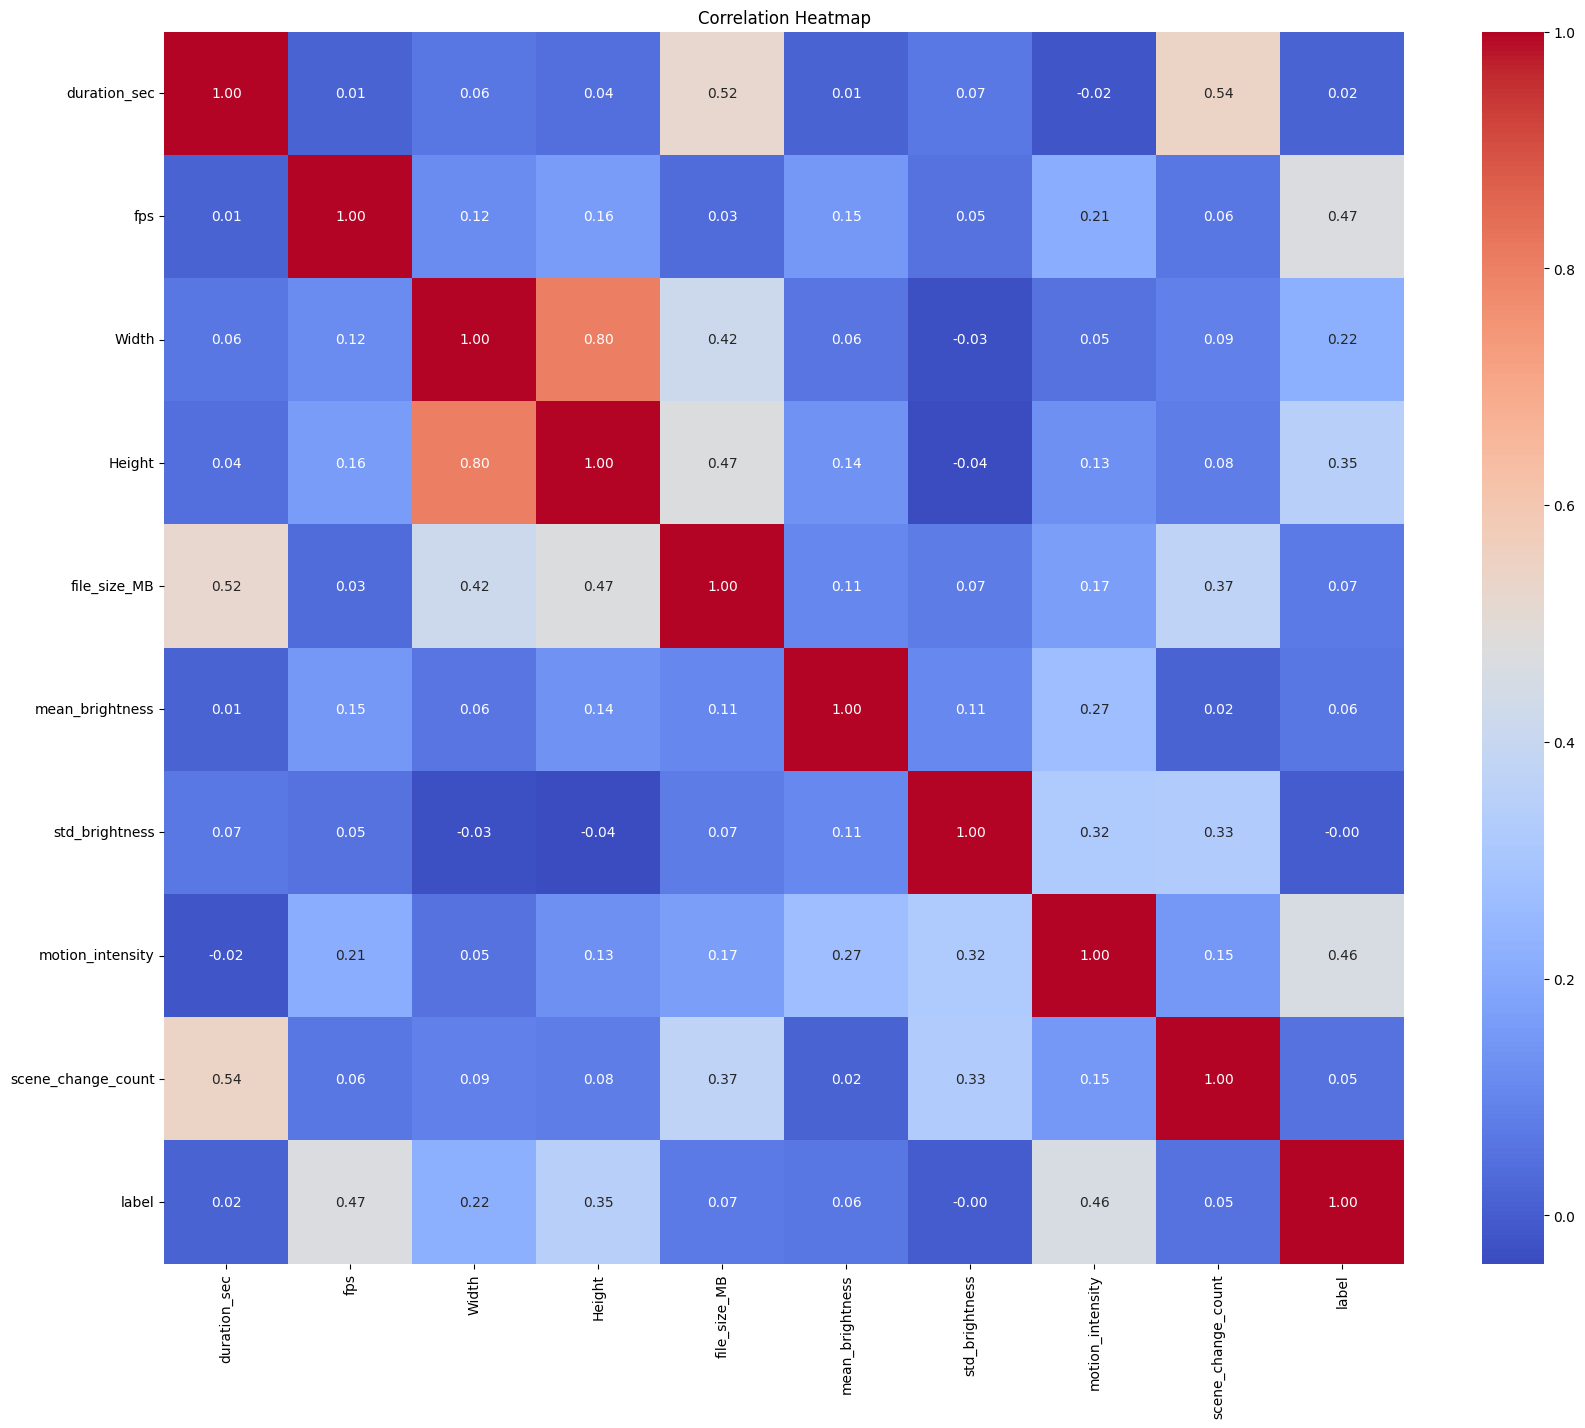

       duration_sec        fps    Width   Height  file_size_MB  \
label                                                            
0          5.102358  24.869857  417.678  318.272      0.819118   
1          5.403268  29.563694  599.100  480.870      1.039316   

       mean_brightness  std_brightness  motion_intensity  scene_change_count  
label                                                                         
0            95.484989        9.967406         11.865470               0.603  
1            99.628355        9.946502         20.589338               0.823  


In [ ]:
# 1. Load data
csv_path = "/content/drive/My Drive/Colab Notebooks/vdp_dataset_merged_final.csv"
df = pd.read_csv(csv_path)

# 2. General info
print("Dataset shape:", df.shape)
print(df['label'].value_counts())

# 3. Distribution plots
numeric_cols = ["duration_sec", "fps", "Width", "Height", "file_size_MB",
                "mean_brightness", "std_brightness",
                "motion_intensity", "scene_change_count"]

for col in numeric_cols:
    plt.figure(figsize=(12,8))
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

# 4. Compare violence vs non-violence
for col in numeric_cols:
    plt.figure(figsize=(12,8))
    sns.boxplot(x="label", y=col, data=df)
    plt.title(f"{col} by label")
    plt.show()

# 5. Correlation heatmap
plt.figure(figsize=(20,16))
sns.heatmap(df[numeric_cols + ["label"]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# 6. Some quick stats
print(df.groupby("label")[numeric_cols].mean())

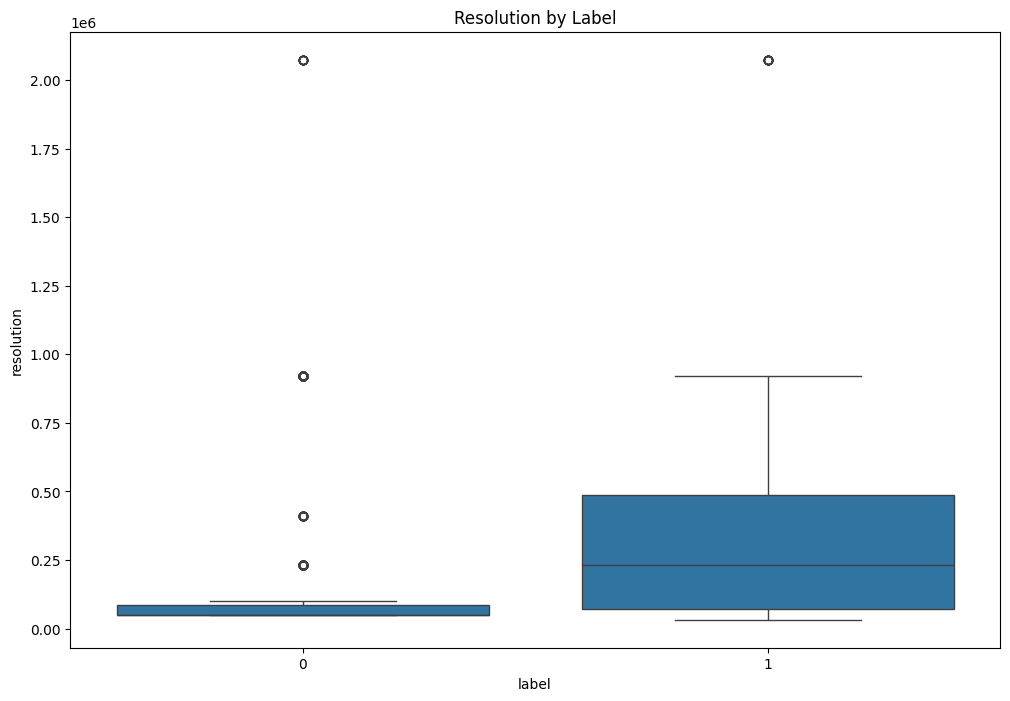

In [ ]:
df["resolution"] = df["Width"] * df["Height"]

plt.figure(figsize=(12,8))
sns.boxplot(x="label", y="resolution", data=df)
plt.title("Resolution by Label")
plt.show()

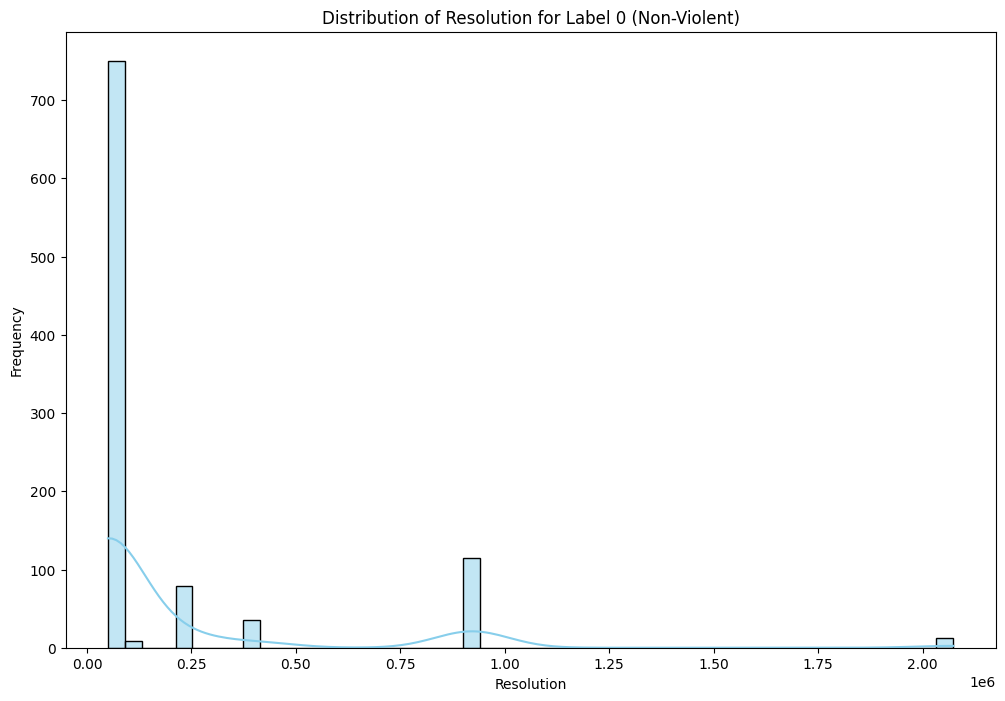

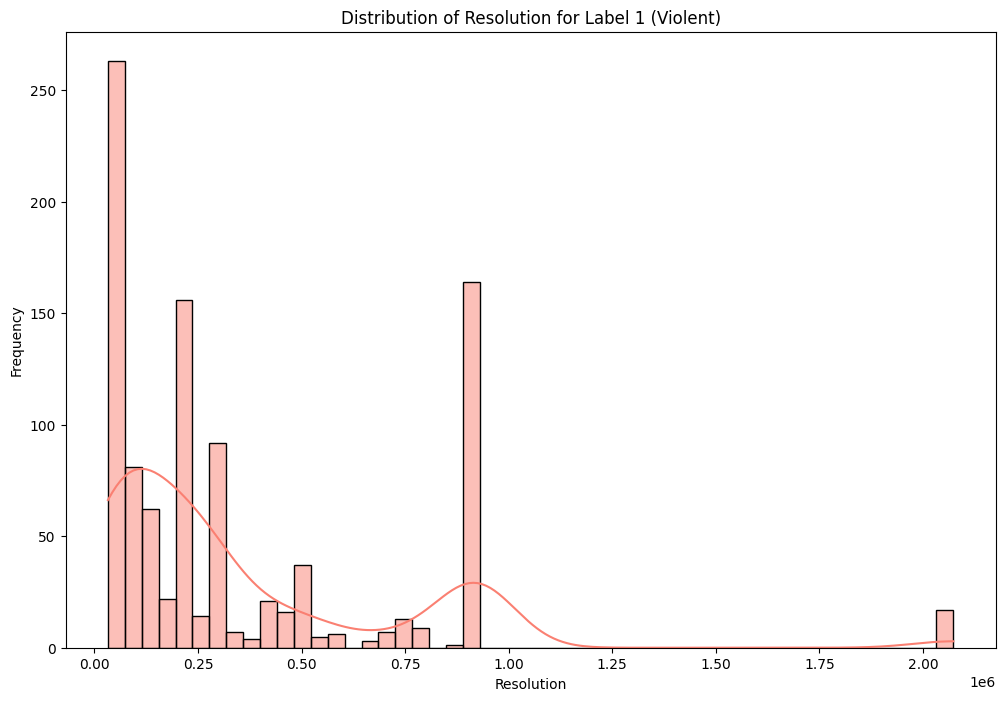

In [ ]:
# Tách dữ liệu theo label
df_label_0 = df[df['label'] == 0]
df_label_1 = df[df['label'] == 1]

# Vẽ histogram cho resolution của nhóm label 0
plt.figure(figsize=(12, 8))
sns.histplot(df_label_0['resolution'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Resolution for Label 0 (Non-Violent)')
plt.xlabel('Resolution')
plt.ylabel('Frequency')
plt.show()

# Vẽ histogram cho resolution của nhóm label 1
plt.figure(figsize=(12, 8))
sns.histplot(df_label_1['resolution'], bins=50, kde=True, color='salmon')
plt.title('Distribution of Resolution for Label 1 (Violent)')
plt.xlabel('Resolution')
plt.ylabel('Frequency')
plt.show()

<Axes: xlabel='label', ylabel='resolution'>

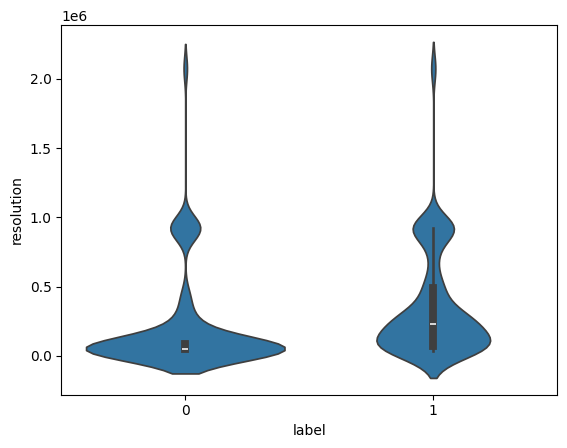

In [ ]:
sns.violinplot(x="label", y="resolution", data=df)

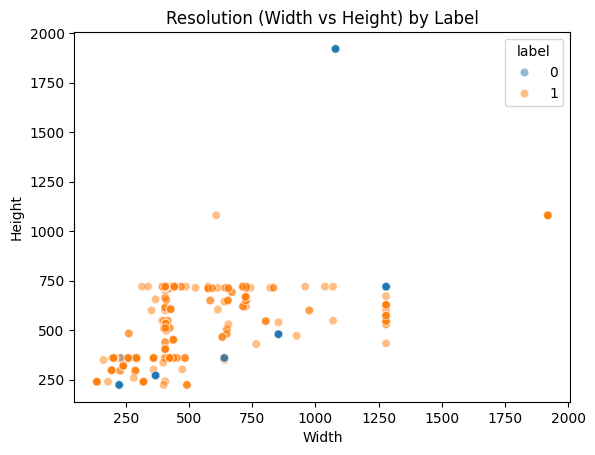

In [ ]:
sns.scatterplot(data=df, x="Width", y="Height", hue="label", alpha=0.5)
plt.title("Resolution (Width vs Height) by Label")
plt.show()

# Task
Train a Random Forest model using the columns ["duration_sec", "fps", "Width", "Height", "file_size_MB", "mean_brightness", "std_brightness", "motion_intensity", "scene_change_count", "label"] from the dataframe `df`. Split the data into 80% for training, 10% for validation, and 10% for testing.

## Chuẩn bị dữ liệu

### Subtask:
Chọn các cột đặc trưng và cột nhãn từ DataFrame `df`.


**Reasoning**:
Select the feature and label columns from the DataFrame as specified in the instructions.



In [ ]:
feature_cols = ["duration_sec", "fps", "Width", "Height", "file_size_MB", "mean_brightness", "std_brightness", "motion_intensity", "scene_change_count"]
label_col = "label"

X = df[feature_cols]
y = df[label_col]

print("Feature columns:", feature_cols)
print("Label column:", label_col)
print("\nShape of feature DataFrame (X):", X.shape)
print("Shape of label Series (y):", y.shape)

Feature columns: ['duration_sec', 'fps', 'Width', 'Height', 'file_size_MB', 'mean_brightness', 'std_brightness', 'motion_intensity', 'scene_change_count']
Label column: label

Shape of feature DataFrame (X): (2000, 9)
Shape of label Series (y): (2000,)


## Chia dữ liệu

### Subtask:
Chia tập dữ liệu thành các tập huấn luyện (80%), validation (10%) và kiểm tra (10%).


**Reasoning**:
Split the data into training, validation, and test sets as instructed.



In [ ]:
from sklearn.model_selection import train_test_split

# Split data into training (80%) and temporary (20%) sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)

# Split temporary set into validation (10%) and test (10%) sets
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Print shapes to confirm splits
print("Shape of X_train:", X_train.shape)
print("Shape of X_val:", X_val.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_val:", y_val.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (1600, 9)
Shape of X_val: (200, 9)
Shape of X_test: (200, 9)
Shape of y_train: (1600,)
Shape of y_val: (200,)
Shape of y_test: (200,)


## Huấn luyện mô hình

### Subtask:
Khởi tạo và huấn luyện mô hình Random Forest trên tập dữ liệu huấn luyện.


**Reasoning**:
Import the necessary class, instantiate the model, and train it on the training data.



In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Instantiate a RandomForestClassifier object
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Fit the model to the training data
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

## Đánh giá mô hình

### Subtask:
Đánh giá hiệu suất của mô hình trên tập dữ liệu validation bằng các chỉ số phù hợp (ví dụ: độ chính xác, precision, recall, F1-score).


**Reasoning**:
Import the necessary metrics from sklearn.metrics to evaluate the model performance.



In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

**Reasoning**:
Use the trained model to make predictions on the validation data and calculate the evaluation metrics.



In [ ]:
y_pred_val = model.predict(X_val)

accuracy = accuracy_score(y_val, y_pred_val)
precision = precision_score(y_val, y_pred_val)
recall = recall_score(y_val, y_pred_val)
f1 = f1_score(y_val, y_pred_val)

print(f"Accuracy on validation set: {accuracy:.4f}")
print(f"Precision on validation set: {precision:.4f}")
print(f"Recall on validation set: {recall:.4f}")
print(f"F1-score on validation set: {f1:.4f}")

Accuracy on validation set: 0.9400
Precision on validation set: 1.0000
Recall on validation set: 0.8788
F1-score on validation set: 0.9355


## Đánh giá cuối cùng

### Subtask:
Đánh giá mô hình trên tập dữ liệu kiểm tra (sau khi hoàn thành điều chỉnh mô hình nếu cần).


**Reasoning**:
Use the trained model to make predictions on the test set and calculate the evaluation metrics.



In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Use the trained model to predict labels on the test set
y_pred_test = model.predict(X_test)

# Calculate evaluation metrics on the test set
accuracy_test = accuracy_score(y_test, y_pred_test)
precision_test = precision_score(y_test, y_pred_test)
recall_test = recall_score(y_test, y_pred_test)
f1_test = f1_score(y_test, y_pred_test)

# Print the evaluation results on the test set
print(f"Accuracy on test set: {accuracy_test:.4f}")
print(f"Precision on test set: {precision_test:.4f}")
print(f"Recall on test set: {recall_test:.4f}")
print(f"F1-score on test set: {f1_test:.4f}")

Accuracy on test set: 0.9300
Precision on test set: 0.9490
Recall on test set: 0.9118
F1-score on test set: 0.9300


## Summary:

### Data Analysis Key Findings

*   The dataset was successfully split into training (80%), validation (10%), and testing (10%) sets, with 1600 samples for training and 200 samples each for validation and testing.
*   A Random Forest Classifier model was trained on the training data.
*   On the validation set, the model achieved an accuracy of 0.9400, a precision of 1.0000, a recall of 0.8788, and an F1-score of 0.9355.
*   On the final test set, the model achieved an accuracy of 0.9300, a precision of 0.9490, a recall of 0.9118, and an F1-score of 0.9300.

### Insights: Data leakage
